# KAFO Optimization

## Notes

This notebook uses one external file: `Winter Gait Biomech.xlsx`.

Nominal subject:
- `BM = 70 kg`
- `H = 1.75 m`

Timing:
- `T_GC = 1.09 s`

In [163]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
})

BM = 70.0
H = 1.75
T_GC = 1.09

EXCEL_FILE = 'Winter Gait Biomech.xlsx'
SHEET_ANGLE = 'angles-natural (3.32b)'
SHEET_MOMENT = 'moment-natural (4.24b)'

if not os.path.exists(EXCEL_FILE):
    alt_file = os.path.join('/mnt/data', EXCEL_FILE)
    if os.path.exists(alt_file):
        EXCEL_FILE = alt_file
    else:
        raise FileNotFoundError(f'Could not find {EXCEL_FILE}')

## 1. Load Data

I use Winter natural-cadence knee angle and knee moment data as the healthy reference.

In [164]:
df_angle = pd.read_excel(EXCEL_FILE, sheet_name=SHEET_ANGLE)
df_moment = pd.read_excel(EXCEL_FILE, sheet_name=SHEET_MOMENT)

# basic checks so the rest of the notebook fails early if the workbook format changed
angle_cols = ['% Cycle', 'Knee Mean', 'Knee Std Dev']
moment_cols = ['% Cycle', 'Knee Mean', 'Knee Std Dev']

if not set(angle_cols).issubset(df_angle.columns):
    raise ValueError(f'Angle sheet must contain columns: {angle_cols}')
if not set(moment_cols).issubset(df_moment.columns):
    raise ValueError(f'Moment sheet must contain columns: {moment_cols}')

if not np.allclose(df_angle['% Cycle'].values.astype(float), df_moment['% Cycle'].values.astype(float)):
    raise ValueError('Angle and moment sheets must use the same % Cycle samples')

print('Knee angle sheet')
print(df_angle[['% Cycle', 'Knee Mean', 'Knee Std Dev']].head(6).to_string(index=False))

print()
print('Knee moment sheet')
print(df_moment[['% Cycle', 'Knee Mean', 'Knee Std Dev']].head(6).to_string(index=False))

print()
print(f'Angle rows: {len(df_angle)}, Moment rows: {len(df_moment)}')
print(f'Angle range: {df_angle["Knee Mean"].min():.2f} to {df_angle["Knee Mean"].max():.2f} deg')
print(f'Moment range: {df_moment["Knee Mean"].min():.3f} to {df_moment["Knee Mean"].max():.3f} Nm/kg')


Knee angle sheet
 % Cycle  Knee Mean  Knee Std Dev
       0       3.97          4.19
       2       7.00          4.58
       4      10.52          4.79
       6      14.12          4.98
       8      17.38          5.11
      10      19.84          5.12

Knee moment sheet
 % Cycle  Knee Mean  Knee Std Dev
       0     -0.196         0.126
       2     -0.281         0.223
       4     -0.090         0.272
       6      0.173         0.291
       8      0.362         0.328
      10      0.508         0.380

Angle rows: 51, Moment rows: 51
Angle range: 0.54 to 64.86 deg
Moment range: -0.281 to 0.615 Nm/kg


## 2. Fit Splines

The raw tables are sampled every 2% of gait cycle. I fit cubic splines so I can evaluate smooth reference profiles and their derivatives.

In [165]:
pct_raw = df_angle['% Cycle'].values.astype(float)
theta_raw = df_angle['Knee Mean'].values.astype(float)
theta_std = df_angle['Knee Std Dev'].values.astype(float)
M_raw_per_kg = df_moment['Knee Mean'].values.astype(float)
M_std_per_kg = df_moment['Knee Std Dev'].values.astype(float)

# cubic splines give smooth reference profiles and smooth first and second derivatives
cs_theta = CubicSpline(pct_raw, theta_raw)
cs_M = CubicSpline(pct_raw, M_raw_per_kg)

# evaluate all reference signals on a common 1% gait-cycle grid
pct = np.arange(0, 101, 1, dtype=float)

theta_ref = cs_theta(pct)
omega_ref = cs_theta(pct, 1)
alpha_ref = cs_theta(pct, 2)
M_ref = cs_M(pct) * BM

# standard deviations are only used for plotting, so linear interpolation is enough here
theta_std_interp = np.interp(pct, pct_raw, theta_std)
M_std = np.interp(pct, pct_raw, M_std_per_kg) * BM

print(f'theta_ref: {theta_ref.min():.2f} to {theta_ref.max():.2f} deg')
print(f'M_ref: {M_ref.min():.2f} to {M_ref.max():.2f} Nm')
print(f'omega_ref: {omega_ref.min():.3f} to {omega_ref.max():.3f} deg/(% cycle)')
print(f'alpha_ref: {alpha_ref.min():.4f} to {alpha_ref.max():.4f} deg/(% cycle)^2')


theta_ref: 0.52 to 64.86 deg
M_ref: -20.01 to 43.05 Nm
omega_ref: -4.107 to 3.441 deg/(% cycle)
alpha_ref: -0.4328 to 0.6787 deg/(% cycle)^2


## 3. Define Stance and Swing

I approximate stance as `0–60%` of the gait cycle and swing as `60–100%`.

In [166]:
TOE_OFF = 60

stance_idx = pct <= TOE_OFF
swing_idx = pct > TOE_OFF

print(f'Stance: {pct[stance_idx].min():.0f}% to {pct[stance_idx].max():.0f}%')
print(f'Swing: {pct[swing_idx].min():.0f}% to {pct[swing_idx].max():.0f}%')

Stance: 0% to 60%
Swing: 61% to 100%


## 4. Define `M_flex`

`M_flex` is the positive stance-phase support demand:

`M_flex(t) = max(0, M_ref(t))` for `t` in stance.

This keeps only the part of the knee moment curve that I use as extensor support demand.

In [167]:
M_flex = np.zeros_like(M_ref)
M_flex[stance_idx] = np.maximum(0.0, M_ref[stance_idx])

peak_flex = M_flex.max()
peak_pct = pct[np.argmax(M_flex)]

print(f'Peak M_flex = {peak_flex:.2f} Nm at {peak_pct:.0f}% gait cycle')
nz = pct[M_flex > 0]
print(f'Non-zero M_flex: {nz.min():.0f}% to {nz.max():.0f}% gait cycle')

Peak M_flex = 43.05 Nm at 14% gait cycle
Non-zero M_flex: 5% to 60% gait cycle


## 5. Compute `I_eq`

I model the shank-foot system with one equivalent rotational inertia about the knee.

For each segment:

`I_knee = I_cm + m d^2`, with `I_cm = m k^2`

In [168]:
# shank
m_s = 0.0465 * BM
L_s = 0.246 * H
d_s = 0.433 * L_s
k_s = 0.302 * L_s
I_cm_s = m_s * k_s**2
I_knee_s = I_cm_s + m_s * d_s**2

# foot
m_f = 0.0145 * BM
L_f = 0.152 * H
d_f_h = 0.50 * L_f

# assume the foot is roughly perpendicular to the shank, so knee-to-foot-COM distance
# is the hypotenuse made by shank length and half-foot length
d_f = np.sqrt(L_s**2 + d_f_h**2)

k_f = 0.475 * L_f
I_cm_f = m_f * k_f**2
I_knee_f = I_cm_f + m_f * d_f**2

# equivalent inertia is the shank and foot inertia lumped about the knee
I_eq = I_knee_s + I_knee_f

print('Winter anthropometric parameters')
print(f'm_s = {m_s:.4f} kg')
print(f'L_s = {L_s:.4f} m')
print(f'd_s = {d_s:.4f} m')
print(f'I_knee_s = {I_knee_s:.6f} kg·m²')
print()
print(f'm_f = {m_f:.4f} kg')
print(f'L_f = {L_f:.4f} m')
print(f'd_f = {d_f:.4f} m')
print(f'I_knee_f = {I_knee_f:.6f} kg·m²')
print()
print(f'I_eq = {I_eq:.5f} kg·m²')


Winter anthropometric parameters
m_s = 3.2550 kg
L_s = 0.4305 m
d_s = 0.1864 m
I_knee_s = 0.168122 kg·m²

m_f = 1.0150 kg
L_f = 0.2660 m
d_f = 0.4506 m
I_knee_f = 0.222268 kg·m²

I_eq = 0.39039 kg·m²


## 6. Check the Reference Profiles

These plots show the spline fit for the knee angle and the rectified stance support demand.

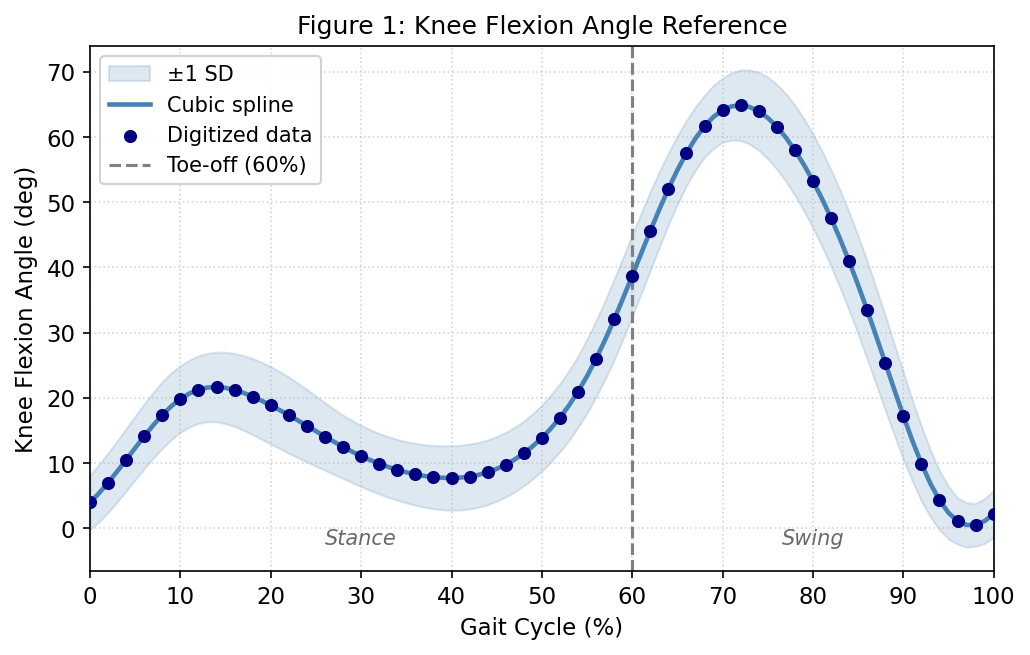

In [169]:
fig1, ax1 = plt.subplots(figsize=(7, 4.5))

ax1.fill_between(
    pct,
    theta_ref - theta_std_interp,
    theta_ref + theta_std_interp,
    alpha=0.18,
    color='steelblue',
    label='±1 SD',
)
ax1.plot(pct, theta_ref, color='steelblue', lw=2.2, label='Cubic spline')
ax1.scatter(
    pct_raw,
    theta_raw,
    s=28,
    zorder=5,
    color='navy',
    marker='o',
    label='Digitized data',
)
ax1.axvline(TOE_OFF, color='gray', linestyle='--', lw=1.5, label=f'Toe-off ({TOE_OFF}%)')

ylo, yhi = ax1.get_ylim()
ax1.text(30, ylo + 0.05 * (yhi - ylo), 'Stance', ha='center', fontsize=10, color='dimgray', style='italic')
ax1.text(80, ylo + 0.05 * (yhi - ylo), 'Swing', ha='center', fontsize=10, color='dimgray', style='italic')

ax1.set_xlabel('Gait Cycle (%)')
ax1.set_ylabel('Knee Flexion Angle (deg)')
ax1.set_title('Figure 1: Knee Flexion Angle Reference')
ax1.legend(loc='upper left', framealpha=0.9)
ax1.set_xlim(0, 100)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.grid(True, linestyle=':', alpha=0.5)

fig1.tight_layout()
fig1.savefig('Figure1_KneeAngle.png', dpi=300, bbox_inches='tight')
plt.show()

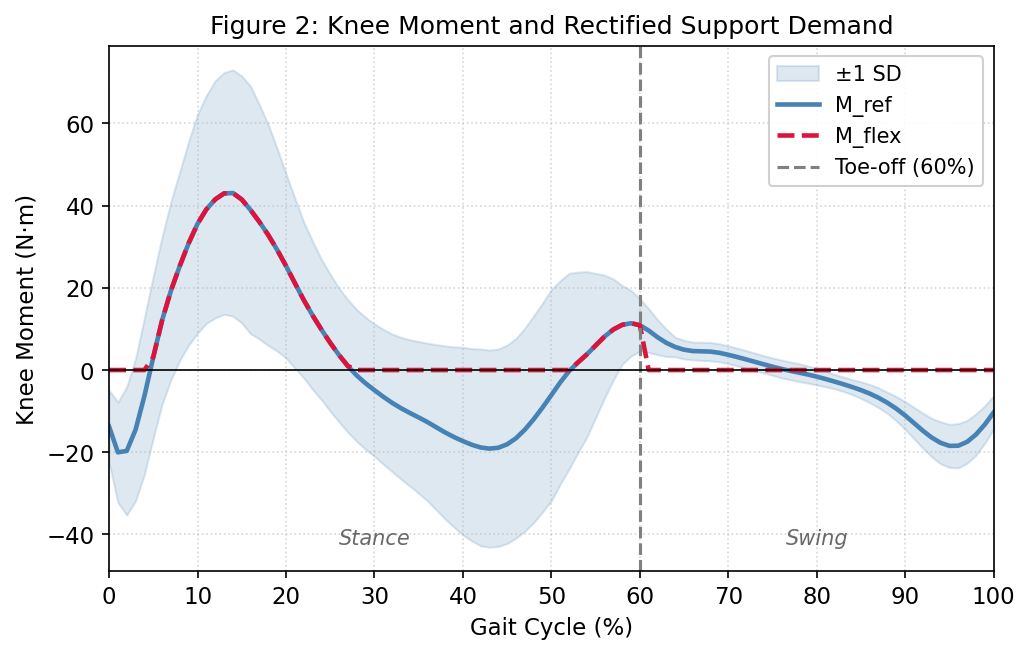

In [170]:
fig2, ax2 = plt.subplots(figsize=(7, 4.5))

ax2.fill_between(pct, M_ref - M_std, M_ref + M_std, alpha=0.18, color='steelblue', label='±1 SD')
ax2.plot(pct, M_ref, color='steelblue', lw=2.2, label='M_ref')
ax2.plot(pct, M_flex, color='crimson', lw=2.2, ls='--', label='M_flex')
ax2.axvline(TOE_OFF, color='gray', linestyle='--', lw=1.5, label=f'Toe-off ({TOE_OFF}%)')
ax2.axhline(0.0, color='black', lw=0.8)

ylo2, yhi2 = ax2.get_ylim()
ax2.text(30, ylo2 + 0.05 * (yhi2 - ylo2), 'Stance', ha='center', fontsize=10, color='dimgray', style='italic')
ax2.text(80, ylo2 + 0.05 * (yhi2 - ylo2), 'Swing', ha='center', fontsize=10, color='dimgray', style='italic')

ax2.set_xlabel('Gait Cycle (%)')
ax2.set_ylabel('Knee Moment (N·m)')
ax2.set_title('Figure 2: Knee Moment and Rectified Support Demand')
ax2.legend(loc='upper right', framealpha=0.9)
ax2.set_xlim(0, 100)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax2.grid(True, linestyle=':', alpha=0.5)

fig2.tight_layout()
fig2.savefig('Figure2_KneeMoment.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Convert to Time and SI Units

The spline derivatives start in gait-cycle units, so I convert them to physical time units using one gait-cycle duration:

`T_cycle = T_GC = 1.09 s`

In [171]:
from scipy.integrate import solve_ivp

T_cycle = T_GC
T_stance = TOE_OFF / 100.0 * T_cycle
T_swing = T_cycle - T_stance

t_cycle = pct / 100.0 * T_cycle
stance_t = t_cycle[stance_idx]
swing_t = t_cycle[swing_idx]

# spline derivatives start in deg per % gait cycle, so convert them to SI time units
theta_ref_rad = np.deg2rad(theta_ref)
omega_ref_rad = np.deg2rad(omega_ref) * (100.0 / T_cycle)
alpha_ref_rad = np.deg2rad(alpha_ref) * (100.0 / T_cycle) ** 2

def theta_ref_fn(t):
    return np.interp(t, t_cycle, theta_ref_rad)

def omega_ref_fn(t):
    return np.interp(t, t_cycle, omega_ref_rad)

def M_flex_fn(t):
    return np.interp(t, stance_t, M_flex[stance_idx], left=M_flex[stance_idx][0], right=0.0)

print(f'T_cycle = {T_cycle:.3f} s')
print(f'T_stance = {T_stance:.3f} s')
print(f'T_swing = {T_swing:.3f} s')
print(f'Peak |omega_ref| = {np.max(np.abs(omega_ref_rad)):.3f} rad/s')
print(f'Peak |alpha_ref| = {np.max(np.abs(alpha_ref_rad)):.2f} rad/s²')


T_cycle = 1.090 s
T_stance = 0.654 s
T_swing = 0.436 s
Peak |omega_ref| = 6.576 rad/s
Peak |alpha_ref| = 99.71 rad/s²


## 8. Reduced-Order Knee Model

This is a reduced-order, reference-tracking model. The states are knee angle error and velocity error relative to the healthy reference.

States:
- `e(t) = theta_k(t) - theta_ref(t)`
- `v(t) = omega_k(t) - omega_ref(t)`

Dynamics:
- `e_dot = v`
- `I_eq * v_dot = M_flex(t) - tau_quad(t) - tau_spring(theta_k) - b v - I_eq * alpha_ref(t) - b * omega_ref(t)`

Quadriceps model:
- `tau_des = M_flex(t) - tau_spring + Kp e + Kd v`
- `tau_quad = clip(tau_des, 0, alpha T_norm)`

In [185]:
theta0_deg = 0.0
theta0_rad = np.deg2rad(theta0_deg)

T_norm = float(M_flex.max())
DEV_LIMIT_DEG = 5.0

wn = 8.0
zeta = 1.0
b = 0.4

# choose PD gains from a second-order target response using the lumped inertia
Kp = I_eq * wn**2
Kd = max(0.0, 2.0 * zeta * wn * I_eq - b)

print(f'T_norm = {T_norm:.2f} N·m')
print(f'DEV_LIMIT_DEG = {DEV_LIMIT_DEG:.1f} deg')
print(f'Kp = {Kp:.4f}')
print(f'Kd = {Kd:.4f}')


T_norm = 43.05 N·m
DEV_LIMIT_DEG = 5.0 deg
Kp = 24.9850
Kd = 5.8462


In [186]:
def spring_torque(theta, k_deg):
    theta = np.asarray(theta, dtype=float)

    # k is defined in N·m/deg, but the simulation state is in radians
    k_rad = k_deg * (180.0 / np.pi)

    # unilateral spring: it only resists flexion beyond theta0
    return k_rad * np.maximum(theta - theta0_rad, 0.0)


def simulate_case(alpha_strength, k_deg, I=None, b_damp=None, T_norm_scale=1.0):
    I_use = I_eq if I is None else float(I)
    b_use = b if b_damp is None else float(b_damp)
    Tn = T_norm * T_norm_scale

    if I is None:
        Kp_use, Kd_use = Kp, Kd
    else:
        Kp_use = I_use * wn**2
        Kd_use = max(0.0, 2.0 * zeta * wn * I_use - b_use)

    def rhs(t, y):
        e, v = y
        theta_k = theta_ref_fn(t) + e
        tau_sp = float(spring_torque(theta_k, k_deg))
        mflex = M_flex_fn(t)

        # desired quadriceps torque is the remaining support demand plus PD correction
        tau_des = mflex - tau_sp + Kp_use * e + Kd_use * v

        # weakness is modeled as a hard cap on available quadriceps torque
        tau_q = float(np.clip(tau_des, 0.0, alpha_strength * Tn))
        alpha_ref_t = np.interp(t, t_cycle, alpha_ref_rad)
        omega_ref_t = np.interp(t, t_cycle, omega_ref_rad)
        v_dot = (mflex - tau_q - tau_sp - b_use * v - I_use * alpha_ref_t - b_use * omega_ref_t) / I_use

        return [v, v_dot]

    sol = solve_ivp(
        rhs,
        [stance_t[0], stance_t[-1]],
        [0.0, 0.0],
        t_eval=stance_t,
        method='RK45',
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        warnings.warn(f'solve_ivp failed for alpha={alpha_strength}, k={k_deg}: {sol.message}')

    t_out = sol.t
    e_out = sol.y[0]
    v_out = sol.y[1]
    theta_k_out = theta_ref_fn(t_out) + e_out

    tau_quad_out = np.empty_like(t_out)
    tau_spring_out = np.empty_like(t_out)

    for i, (ti, ei, vi) in enumerate(zip(t_out, e_out, v_out)):
        theta_k_i = theta_ref_fn(ti) + ei
        tau_sp_i = float(spring_torque(theta_k_i, k_deg))
        mflex_i = M_flex_fn(ti)
        tau_des_i = mflex_i - tau_sp_i + Kp_use * ei + Kd_use * vi
        tau_quad_out[i] = float(np.clip(tau_des_i, 0.0, alpha_strength * Tn))
        tau_spring_out[i] = tau_sp_i

    return {
        't': t_out,
        'e': e_out,
        'theta_deg': np.rad2deg(theta_k_out),
        'tau_quad': tau_quad_out,
        'tau_spring': tau_spring_out,
    }


def evaluate_case(alpha_strength, k_deg, **model_kwargs):
    sim = simulate_case(alpha_strength, k_deg, **model_kwargs)

    e_deg = np.rad2deg(sim['e'])
    theta_deg = sim['theta_deg']
    t = sim['t']
    tau_quad = sim['tau_quad']
    tau_spring = sim['tau_spring']

    # positive e means extra flexion relative to the healthy reference
    max_dev = float(np.max(e_deg))
    min_theta = float(np.min(theta_deg))
    theta_max = float(np.max(theta_deg))
    J_quad = float(np.trapezoid(tau_quad**2, t))
    peak_tau_quad = float(np.max(tau_quad))
    peak_tau_spring = float(np.max(tau_spring))

    return {
        'sim': sim,
        'max_flexion_deviation_deg': max_dev,
        'min_theta_sim_deg': min_theta,
        'theta_max_deg': theta_max,
        'J_quad': J_quad,
        'peak_tau_quad': peak_tau_quad,
        'peak_tau_spring': peak_tau_spring,
    }


print('Core model functions defined.')


Core model functions defined.


## 9. Choose Spring Stiffness

For each weakness level, I choose the smallest spring stiffness that keeps the maximum stance deviation within the allowed limit.

In [174]:
def optimize_for_alpha(alpha_strength, k_grid, dev_limit_deg=DEV_LIMIT_DEG, **model_kwargs):
    rows = []
    cache = {}

    for k_deg in k_grid:
        case = evaluate_case(alpha_strength, k_deg, **model_kwargs)
        cache[float(k_deg)] = case
        rows.append({
            'alpha': alpha_strength,
            'k_deg': float(k_deg),
            'max_flexion_deviation_deg': case['max_flexion_deviation_deg'],
            'min_theta_sim_deg': case['min_theta_sim_deg'],
            'theta_max_deg': case['theta_max_deg'],
            'J_quad': case['J_quad'],
            'peak_tau_quad': case['peak_tau_quad'],
            'peak_tau_spring': case['peak_tau_spring'],
        })

    df = pd.DataFrame(rows)
    df['feasible'] = df['max_flexion_deviation_deg'] <= dev_limit_deg

    feasible = df[df['feasible']]
    if len(feasible) == 0:
        idx = df['max_flexion_deviation_deg'].idxmin()
        best = df.loc[idx].copy()
        best['selection_note'] = 'infeasible: min deviation'
    else:
        idx = feasible['k_deg'].idxmin()
        best = feasible.loc[idx].copy()
        best['selection_note'] = 'feasible: min k'

    return df, cache, best


def run_search(alpha_values, dev_limit_deg=DEV_LIMIT_DEG, k_min=0.0, k_max=5.0, coarse_step=0.25, fine_step=0.05):
    alpha_values = np.asarray(alpha_values, dtype=float)
    k_grid_coarse = np.round(np.arange(k_min, k_max + 0.001, coarse_step), 2)

    rows = []
    for alpha_s in alpha_values:
        df_coarse, _, best_coarse = optimize_for_alpha(alpha_s, k_grid_coarse, dev_limit_deg=dev_limit_deg)

        k_best = float(best_coarse['k_deg'])
        if fine_step is not None and str(best_coarse.get('selection_note', '')).startswith('feasible'):
            k_fine_min = max(k_min, k_best - 0.5)
            k_fine_max = min(k_max, k_best + 0.5)
            k_grid_fine = np.round(np.arange(k_fine_min, k_fine_max + 0.001, fine_step), 2)
            _, _, best = optimize_for_alpha(alpha_s, k_grid_fine, dev_limit_deg=dev_limit_deg)
        else:
            best = best_coarse

        rows.append({
            'alpha': float(best['alpha']),
            'k_deg': float(best['k_deg']),
            'max_flexion_deviation_deg': float(best['max_flexion_deviation_deg']),
            'min_theta_sim_deg': float(best['min_theta_sim_deg']),
            'theta_max_deg': float(best['theta_max_deg']),
            'J_quad': float(best['J_quad']),
            'peak_tau_quad': float(best['peak_tau_quad']),
            'peak_tau_spring': float(best['peak_tau_spring']),
            'selection_note': str(best.get('selection_note', '')),
        })

    return pd.DataFrame(rows).sort_values('alpha').reset_index(drop=True)


## 10. Run the Search

I run the search for `alpha = 0.30, 0.40, 0.50, 0.60, 0.70` with a coarse grid first, then a fine grid around the best coarse result when a feasible region exists.

In [175]:
alpha_levels = np.array([0.30, 0.40, 0.50, 0.60, 0.70])
k_grid_coarse = np.round(np.arange(0.0, 5.001, 0.25), 2)

opt_results = {}
recommended_rows = []

for alpha_s in alpha_levels:
    print(f'Optimizing alpha = {alpha_s:.2f} ...', end=' ', flush=True)

    df_coarse, cache_coarse, best_coarse = optimize_for_alpha(alpha_s, k_grid_coarse)

    k_best_coarse = float(best_coarse['k_deg'])
    if str(best_coarse.get('selection_note', '')).startswith('feasible'):
        k_fine_min = max(0.0, k_best_coarse - 0.5)
        k_fine_max = min(5.0, k_best_coarse + 0.5)
        k_grid_fine = np.round(np.arange(k_fine_min, k_fine_max + 0.001, 0.05), 2)
        df_a, cache_a, best_a = optimize_for_alpha(alpha_s, k_grid_fine)
        merged_cache = {**cache_coarse, **cache_a}
    else:
        df_a, merged_cache, best_a = df_coarse, cache_coarse, best_coarse

    opt_results[float(alpha_s)] = {'grid': df_a, 'cache': merged_cache, 'best': best_a}

    recommended_rows.append({
        'alpha': float(best_a['alpha']),
        'k_deg': float(best_a['k_deg']),
        'max_flexion_deviation_deg': float(best_a['max_flexion_deviation_deg']),
        'min_theta_sim_deg': float(best_a['min_theta_sim_deg']),
        'theta_max_deg': float(best_a['theta_max_deg']),
        'J_quad': float(best_a['J_quad']),
        'peak_tau_quad': float(best_a['peak_tau_quad']),
        'peak_tau_spring': float(best_a['peak_tau_spring']),
        'selection_note': str(best_a.get('selection_note', '')),
    })
    print('done')

recommended = pd.DataFrame(recommended_rows).sort_values('alpha').reset_index(drop=True)

display(recommended[['alpha', 'k_deg', 'max_flexion_deviation_deg', 'min_theta_sim_deg',
                     'theta_max_deg', 'J_quad', 'peak_tau_spring', 'selection_note']])


Optimizing alpha = 0.30 ... done
Optimizing alpha = 0.40 ... done
Optimizing alpha = 0.50 ... done
Optimizing alpha = 0.60 ... done
Optimizing alpha = 0.70 ... done


,alpha,k_deg,max_flexion_deviation_deg,min_theta_sim_deg,theta_max_deg,J_quad,peak_tau_spring,selection_note
0,0.3,1.70,4.361290,-74.269691,20.756012,17.232676,35.285220,feasible: min k
1,0.4,1.45,4.694557,-66.574358,20.899481,30.682199,30.304247,feasible: min k
2,0.5,1.25,4.703223,-59.010332,20.771862,47.008825,25.964828,feasible: min k
3,0.6,1.05,4.987886,-51.900911,21.050381,67.007131,22.102900,feasible: min k
4,0.7,0.90,4.906485,-45.426761,21.012803,87.417848,18.911523,feasible: min k


## 11. Plot the Main Results

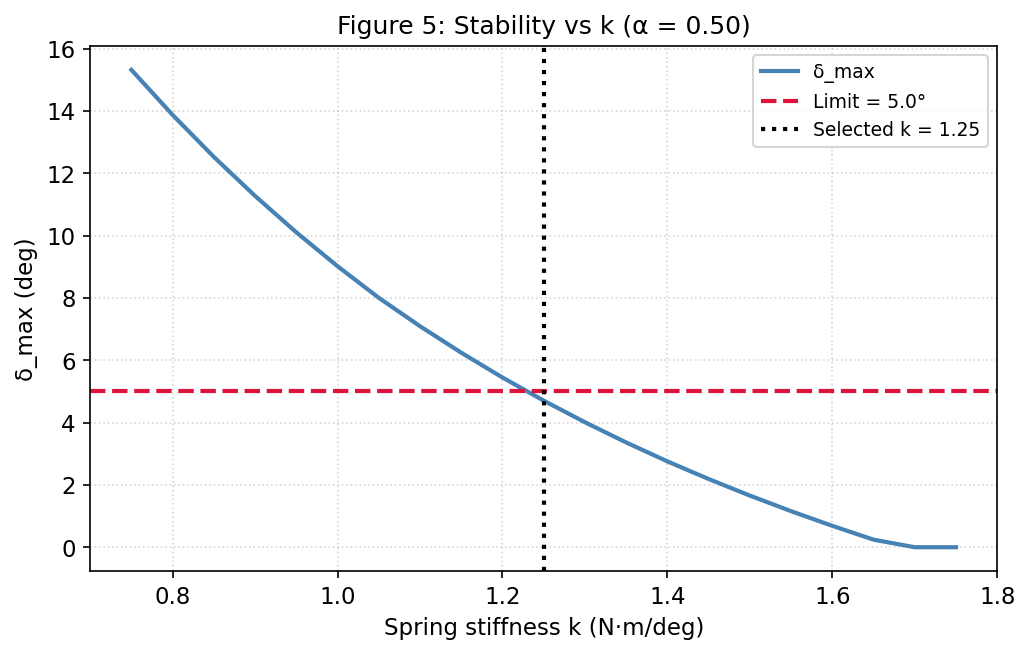

In [176]:
alpha_plot = 0.50
df_plot = opt_results[alpha_plot]['grid']
best_plot = opt_results[alpha_plot]['best']

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(df_plot['k_deg'], df_plot['max_flexion_deviation_deg'], color='steelblue', lw=2, label='δ_max')
ax.axhline(DEV_LIMIT_DEG, color='crimson', ls='--', label=f'Limit = {DEV_LIMIT_DEG}°')
ax.axvline(best_plot['k_deg'], color='black', ls=':', label=f"Selected k = {best_plot['k_deg']:.2f}")
ax.set_xlabel('Spring stiffness k (N·m/deg)')
ax.set_ylabel('δ_max (deg)')
ax.set_title(f'Figure 5: Stability vs k (α = {alpha_plot:.2f})')
ax.legend(fontsize=9)
ax.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig('Figure5_OptimizationMetrics.png', dpi=300, bbox_inches='tight')
plt.show()

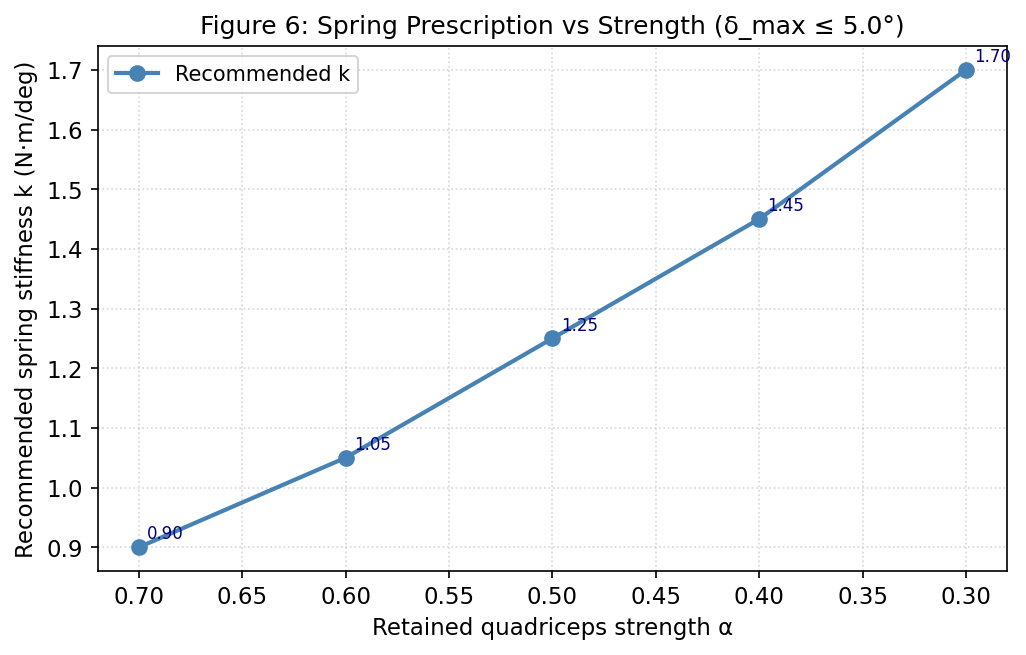


Recommended spring stiffness summary
 alpha  k_deg  max_flexion_deviation_deg  theta_max_deg  selection_note
   0.3   1.70                   4.361290      20.756012 feasible: min k
   0.4   1.45                   4.694557      20.899481 feasible: min k
   0.5   1.25                   4.703223      20.771862 feasible: min k
   0.6   1.05                   4.987886      21.050381 feasible: min k
   0.7   0.90                   4.906485      21.012803 feasible: min k


In [177]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(recommended['alpha'], recommended['k_deg'], marker='o', color='steelblue', lw=2, ms=7, label='Recommended k')

for _, row in recommended.iterrows():
    ax.annotate(
        f"{row['k_deg']:.2f}",
        xy=(row['alpha'], row['k_deg']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=8,
        color='navy',
    )

ax.set_xlabel('Retained quadriceps strength α')
ax.set_ylabel('Recommended spring stiffness k (N·m/deg)')
ax.set_title(f'Figure 6: Spring Prescription vs Strength (δ_max ≤ {DEV_LIMIT_DEG}°)')
ax.invert_xaxis()
ax.grid(True, ls=':', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig('Figure6_SpringPrescription.png', dpi=300, bbox_inches='tight')
plt.show()

print()
print('Recommended spring stiffness summary')
print(recommended[['alpha', 'k_deg', 'max_flexion_deviation_deg', 'theta_max_deg', 'selection_note']].to_string(index=False))

## 12. Plot the Recommended Trajectories

These plots show the recommended stance trajectory for each weakness level.

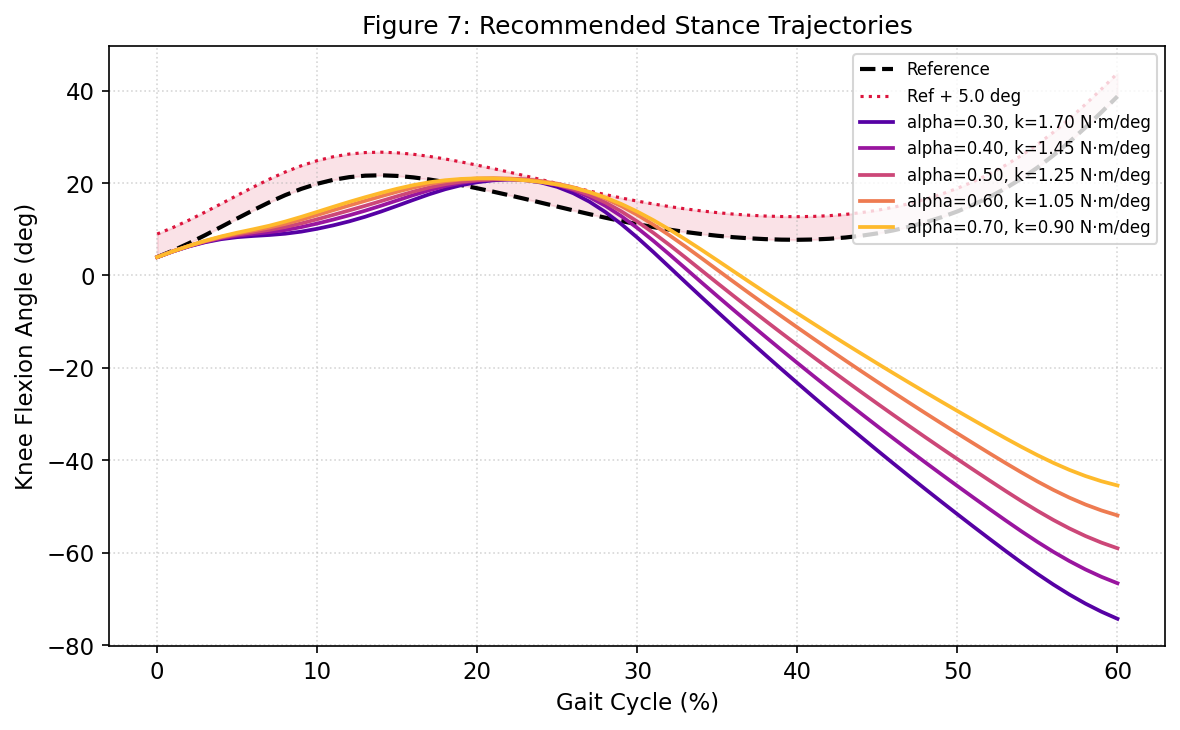

In [178]:
fig, ax = plt.subplots(figsize=(8, 5))

x_ref = 100 * stance_t / T_cycle
ax.plot(x_ref, theta_ref[stance_idx], color='black', ls='--', lw=2, label='Reference')

ax.fill_between(
    x_ref,
    theta_ref[stance_idx],
    theta_ref[stance_idx] + DEV_LIMIT_DEG,
    alpha=0.12,
    color='crimson',
)
ax.plot(
    x_ref,
    theta_ref[stance_idx] + DEV_LIMIT_DEG,
    color='crimson',
    ls=':',
    lw=1.5,
    label=f'Ref + {DEV_LIMIT_DEG} deg',
)

cmap = plt.cm.plasma(np.linspace(0.15, 0.85, len(recommended)))
for idx, (_, row) in enumerate(recommended.iterrows()):
    a_s = float(row['alpha'])
    k_s = float(row['k_deg'])
    cache_a = opt_results[a_s]['cache']
    sim = cache_a[k_s]['sim'] if k_s in cache_a else simulate_case(a_s, k_s)
    ax.plot(
        100 * sim['t'] / T_cycle,
        sim['theta_deg'],
        color=cmap[idx],
        lw=1.8,
        label=f'alpha={a_s:.2f}, k={k_s:.2f} N·m/deg',
    )

ax.set_xlabel('Gait Cycle (%)')
ax.set_ylabel('Knee Flexion Angle (deg)')
ax.set_title('Figure 7: Recommended Stance Trajectories')
ax.grid(True, ls=':', alpha=0.5)
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('Figure7_StanceTrajectories.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Compare No Spring vs Recommended Spring

This compares the no-spring baseline to the recommended spring for each weakness level.

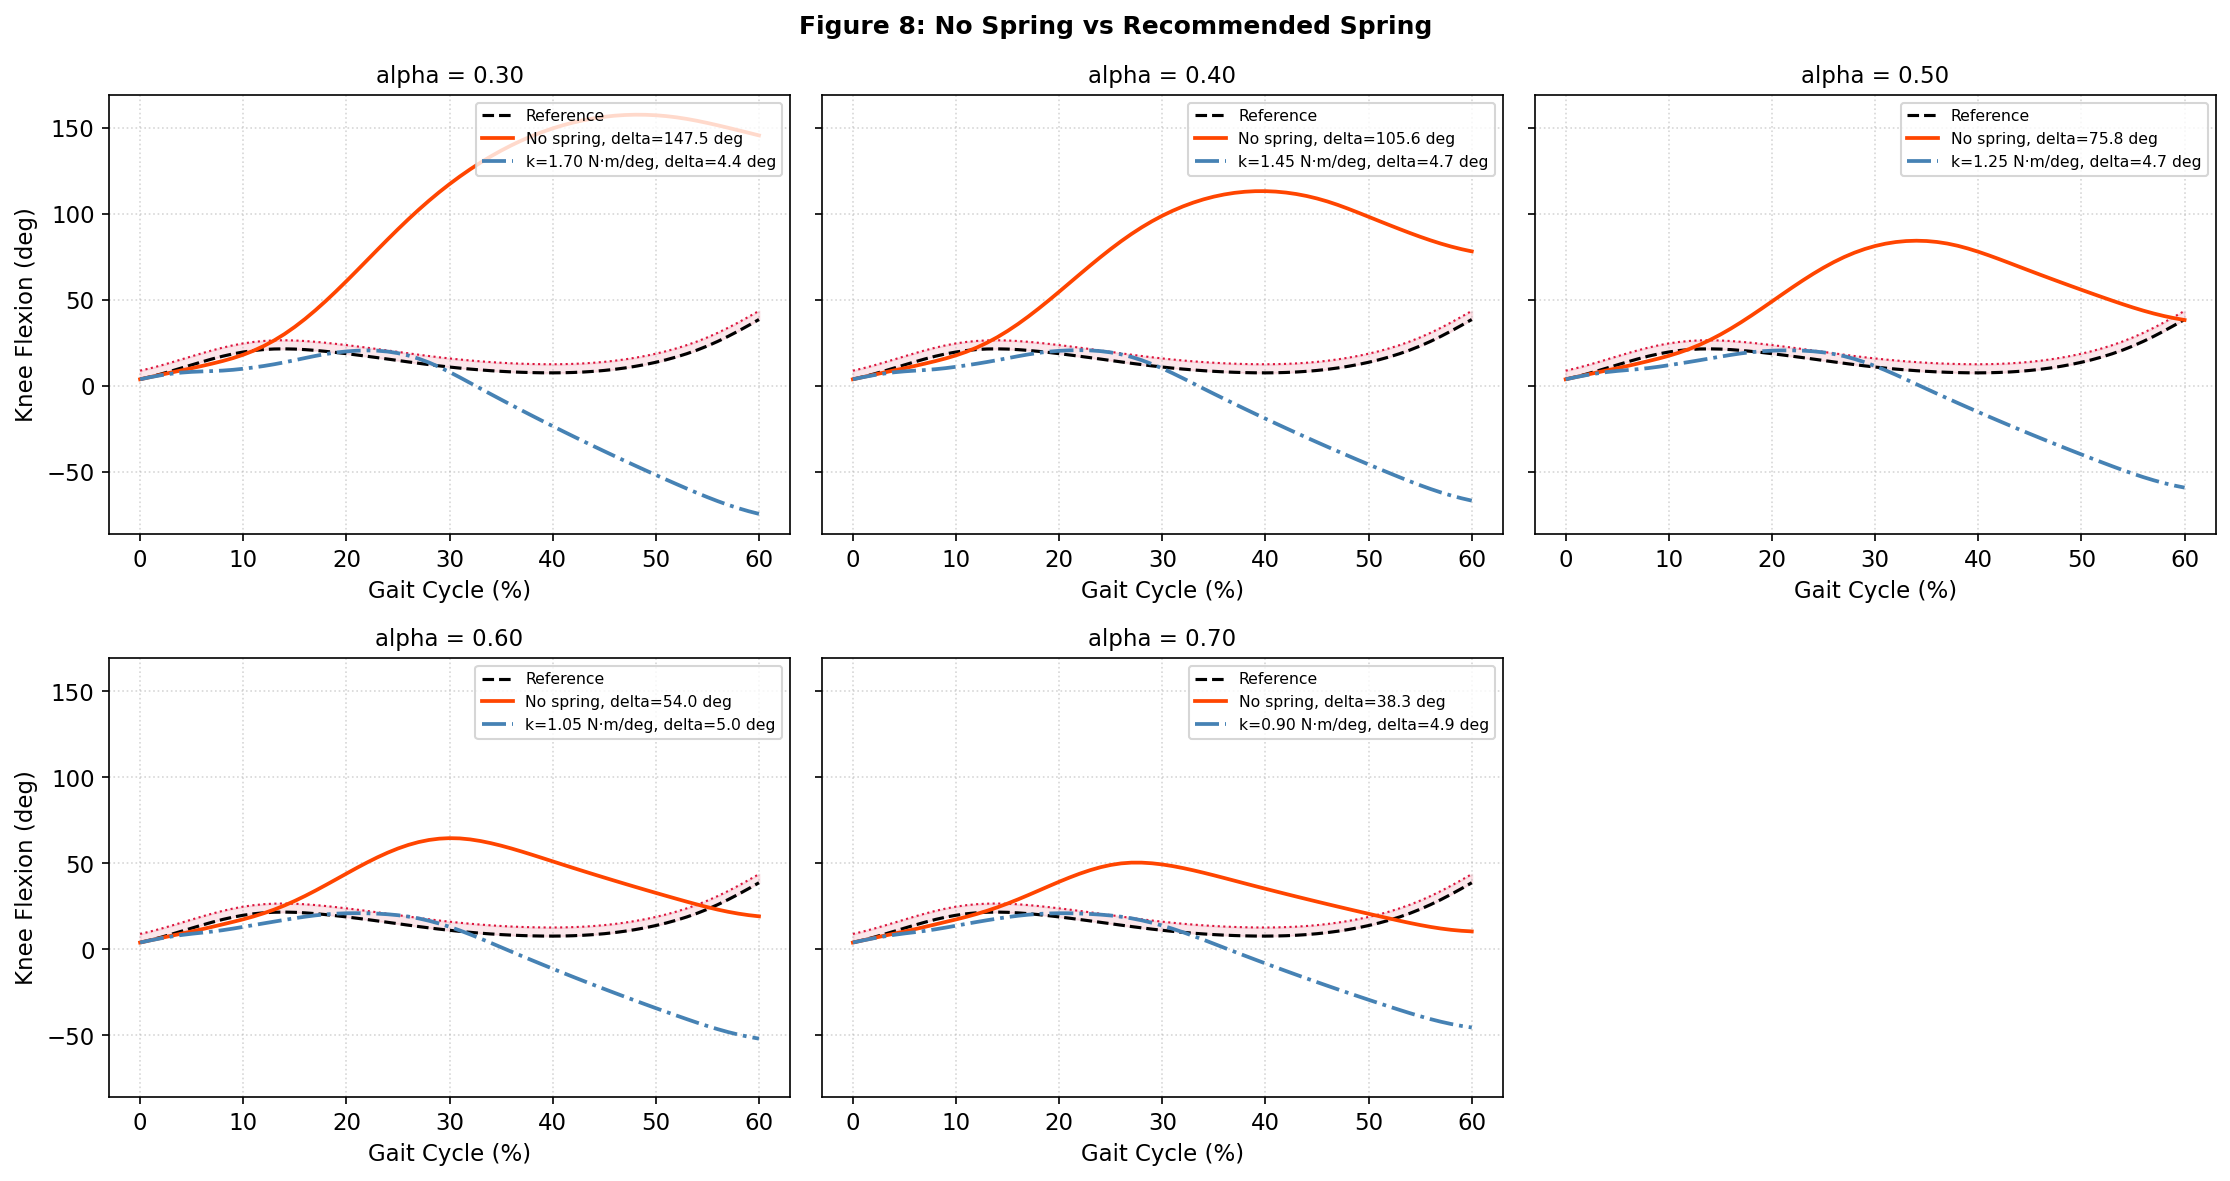


No-spring vs recommended-spring summary
 alpha  delta_max k=0 (deg)  k_rec (N·m/deg)  delta_max k_rec (deg)  improvement (deg)
   0.3               147.45             1.70                   4.36             143.09
   0.4               105.63             1.45                   4.69             100.94
   0.5                75.76             1.25                   4.70              71.05
   0.6                54.04             1.05                   4.99              49.05
   0.7                38.28             0.90                   4.91              33.37


In [179]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes_flat = axes.flatten()

no_spring_rows = []

for i, (_, row) in enumerate(recommended.iterrows()):
    ax = axes_flat[i]
    a_s = float(row['alpha'])
    k_rec = float(row['k_deg'])

    sim_no = simulate_case(a_s, 0.0)
    dev_no = float(np.max(np.rad2deg(sim_no['e'])))

    cache_a = opt_results[a_s]['cache']
    sim_rec = cache_a[k_rec]['sim'] if k_rec in cache_a else simulate_case(a_s, k_rec)
    dev_rec = float(row['max_flexion_deviation_deg'])

    no_spring_rows.append({
        'alpha': a_s,
        'dev_no_spring': dev_no,
        'k_rec': k_rec,
        'dev_recommended': dev_rec,
        'improvement_deg': dev_no - dev_rec,
    })

    x_ref = 100 * stance_t / T_cycle
    ax.plot(x_ref, theta_ref[stance_idx], color='black', ls='--', lw=1.5, label='Reference')
    ax.fill_between(
        x_ref,
        theta_ref[stance_idx],
        theta_ref[stance_idx] + DEV_LIMIT_DEG,
        alpha=0.10,
        color='crimson',
    )
    ax.plot(x_ref, theta_ref[stance_idx] + DEV_LIMIT_DEG, color='crimson', ls=':', lw=1.0)

    ax.plot(
        100 * sim_no['t'] / T_cycle,
        sim_no['theta_deg'],
        color='orangered',
        lw=1.8,
        label=f'No spring, delta={dev_no:.1f} deg',
    )
    ax.plot(
        100 * sim_rec['t'] / T_cycle,
        sim_rec['theta_deg'],
        color='steelblue',
        lw=1.8,
        ls='-.',
        label=f'k={k_rec:.2f} N·m/deg, delta={dev_rec:.1f} deg',
    )

    ax.set_title(f'alpha = {a_s:.2f}', fontsize=11)
    ax.set_xlabel('Gait Cycle (%)')
    if i % 3 == 0:
        ax.set_ylabel('Knee Flexion (deg)')
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, ls=':', alpha=0.5)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Figure 8: No Spring vs Recommended Spring', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig('Figure8_NoSpringComparison.png', dpi=300, bbox_inches='tight')
plt.show()

df_comparison = pd.DataFrame(no_spring_rows)
print()
print('No-spring vs recommended-spring summary')
print(
    df_comparison.rename(
        columns={
            'alpha': 'alpha',
            'dev_no_spring': 'delta_max k=0 (deg)',
            'k_rec': 'k_rec (N·m/deg)',
            'dev_recommended': 'delta_max k_rec (deg)',
            'improvement_deg': 'improvement (deg)',
        }
    ).round(2).to_string(index=False)
)

## 14. Sensitivity to the Allowed Flexion-Deviation Limit

I repeat the spring search for three allowable stance-deviation limits: 4°, 5°, and 6°.

This checks whether the recommended stiffness trend is robust to the main design tolerance in the model.

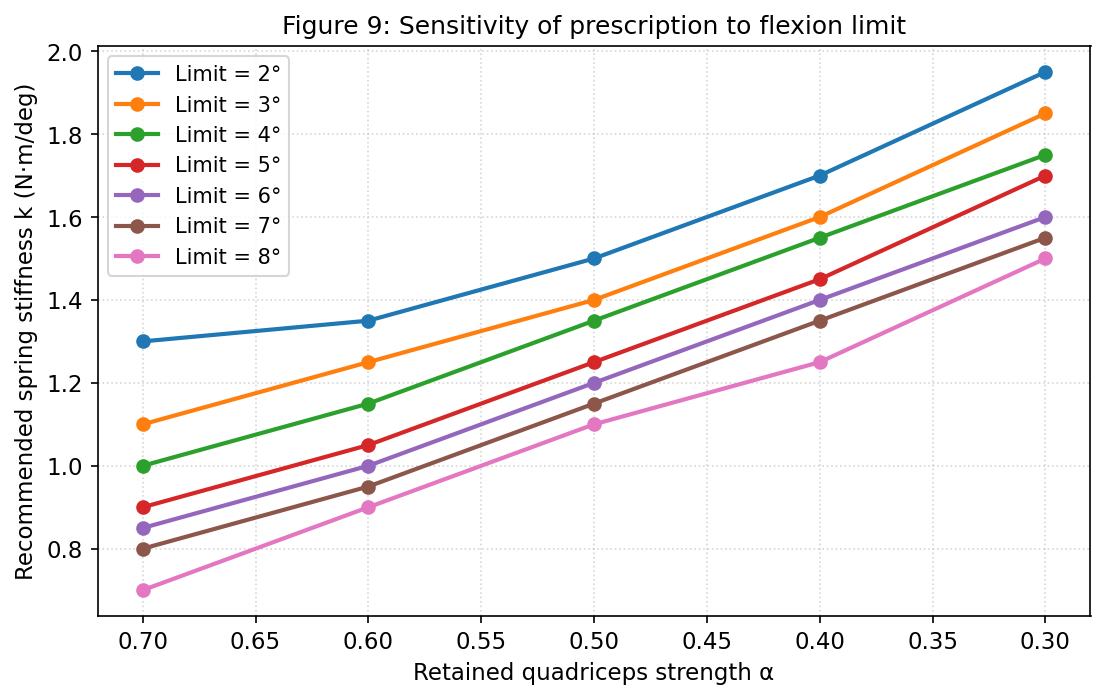


Sensitivity summary
 alpha  k at 2°  k at 3°  k at 4°  k at 5°  k at 6°  k at 7°  k at 8°
   0.3     1.95     1.85     1.75     1.70     1.60     1.55     1.50
   0.4     1.70     1.60     1.55     1.45     1.40     1.35     1.25
   0.5     1.50     1.40     1.35     1.25     1.20     1.15     1.10
   0.6     1.35     1.25     1.15     1.05     1.00     0.95     0.90
   0.7     1.30     1.10     1.00     0.90     0.85     0.80     0.70


In [180]:
dev_limits = [2.0,3.0,4.0,5.0,6.0,7.0,8.0]
sensitivity_rows = []

for dev_lim in dev_limits:
    rec_lim = run_search(alpha_levels, dev_limit_deg=dev_lim, fine_step=0.05)
    rec_lim = rec_lim.copy()
    rec_lim['dev_limit_deg'] = dev_lim
    sensitivity_rows.append(
        rec_lim[['dev_limit_deg', 'alpha', 'k_deg', 'max_flexion_deviation_deg', 'selection_note']]
    )

sensitivity_df = pd.concat(sensitivity_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(7.5, 4.8))

for dev_lim, group in sensitivity_df.groupby('dev_limit_deg'):
    ax.plot(group['alpha'], group['k_deg'], marker='o', lw=2, label=f'Limit = {dev_lim:.0f}°')

ax.set_xlabel('Retained quadriceps strength α')
ax.set_ylabel('Recommended spring stiffness k (N·m/deg)')
ax.set_title('Figure 9: Sensitivity of prescription to flexion limit')
ax.invert_xaxis()
ax.grid(True, ls=':', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig('Figure9_SensitivityDeviationLimit.png', dpi=300, bbox_inches='tight')
plt.show()

sensitivity_table = (sensitivity_df
                     .pivot(index='alpha', columns='dev_limit_deg', values='k_deg')
                     .rename(columns={2.0: 'k at 2°', 3.0: 'k at 3°', 4.0: 'k at 4°', 5.0: 'k at 5°', 6.0: 'k at 6°', 7.0: 'k at 7°', 8.0: 'k at 8°'})
                     .reset_index())

print()
print('Sensitivity summary')
print(sensitivity_table.to_string(index=False))


## 15. Phase portrait (e vs v)

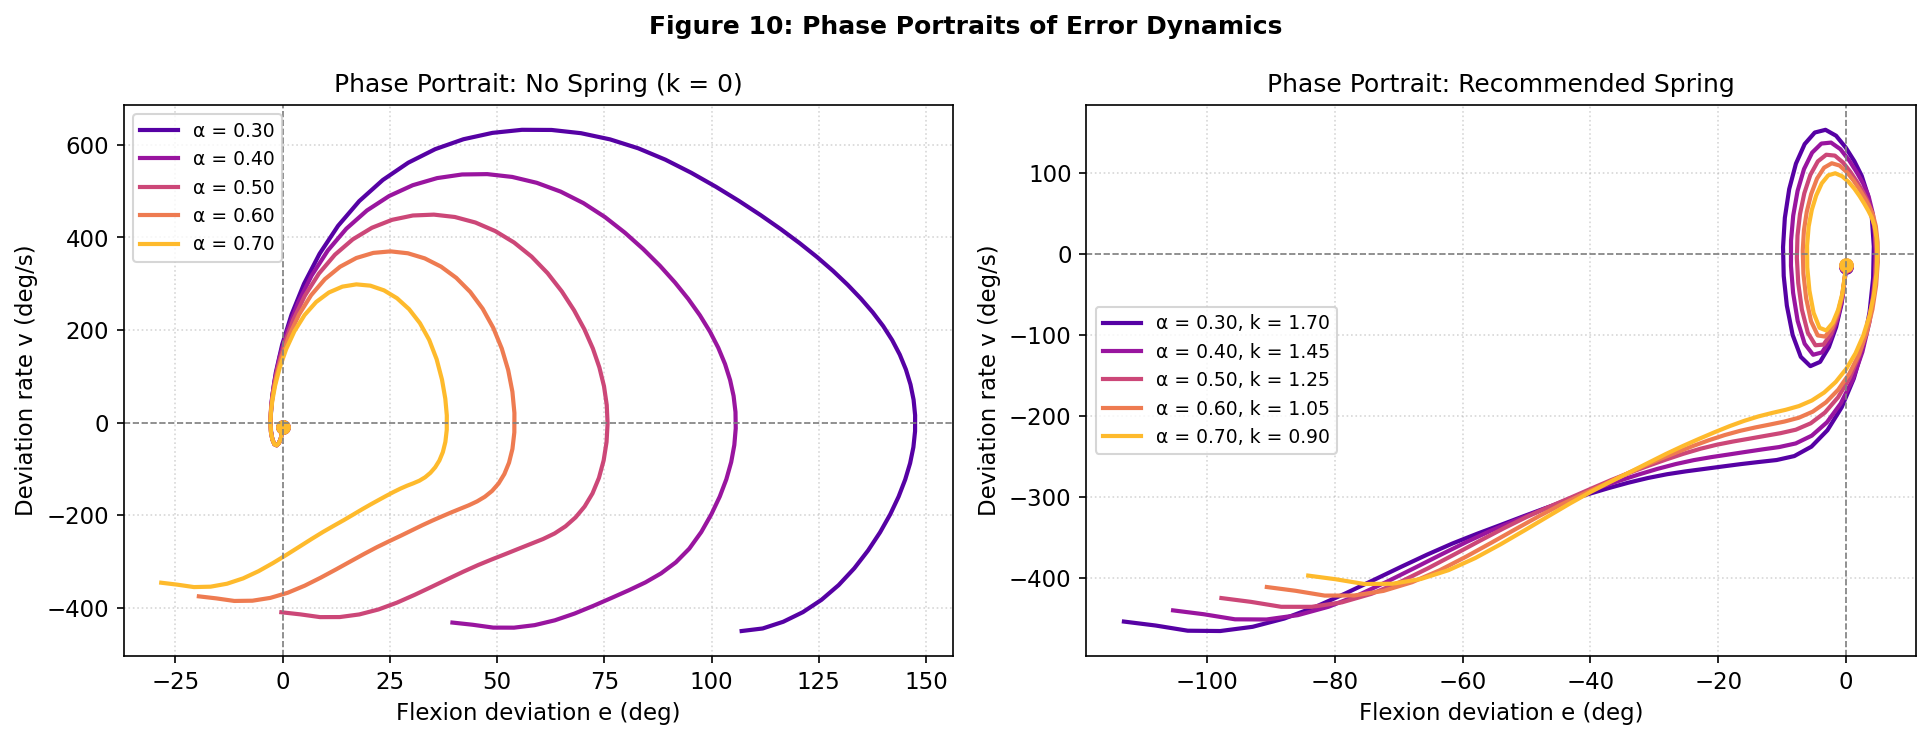

In [181]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(recommended)))

# Left: no spring baseline
ax = axes[0]
for idx, (_, row) in enumerate(recommended.iterrows()):
    a_s = float(row['alpha'])
    sim = simulate_case(a_s, 0.0)
    e_deg = np.rad2deg(sim['e'])
    v_deg = np.rad2deg(np.gradient(sim['e'], sim['t']))
    ax.plot(e_deg, v_deg, color=colors[idx], lw=2, label=f'α = {a_s:.2f}')
    ax.plot(e_deg[0], v_deg[0], 'o', color=colors[idx], ms=6)

ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Flexion deviation e (deg)')
ax.set_ylabel('Deviation rate v (deg/s)')
ax.set_title('Phase Portrait: No Spring (k = 0)')
ax.legend(fontsize=9)
ax.grid(True, ls=':', alpha=0.5)

# Right: recommended spring
ax = axes[1]
for idx, (_, row) in enumerate(recommended.iterrows()):
    a_s = float(row['alpha'])
    k_s = float(row['k_deg'])
    cache_a = opt_results[a_s]['cache']
    sim = cache_a[k_s]['sim'] if k_s in cache_a else simulate_case(a_s, k_s)
    e_deg = np.rad2deg(sim['e'])
    v_deg = np.rad2deg(np.gradient(sim['e'], sim['t']))
    ax.plot(e_deg, v_deg, color=colors[idx], lw=2, label=f'α = {a_s:.2f}, k = {k_s:.2f}')
    ax.plot(e_deg[0], v_deg[0], 'o', color=colors[idx], ms=6)

ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Flexion deviation e (deg)')
ax.set_ylabel('Deviation rate v (deg/s)')
ax.set_title('Phase Portrait: Recommended Spring')
ax.legend(fontsize=9)
ax.grid(True, ls=':', alpha=0.5)

plt.suptitle('Figure 10: Phase Portraits of Error Dynamics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure10_PhasePortrait.png', dpi=300, bbox_inches='tight')
plt.show()

## 16. Sensitivity to b

Sensitivity to damping coefficient b
 alpha  k (b=0.0)  k (b=0.1)  k (b=0.2)  k (b=0.4)  k (b=0.8)  k (b=1)  k (b=2)
   0.3       1.70       1.70       1.70       1.70       1.65      1.6     1.50
   0.4       1.50       1.50       1.50       1.45       1.40      1.4     1.30
   0.5       1.30       1.30       1.30       1.25       1.20      1.2     1.05
   0.6       1.15       1.10       1.10       1.05       1.00      1.0     0.85
   0.7       1.00       0.95       0.95       0.90       0.85      0.8     0.70


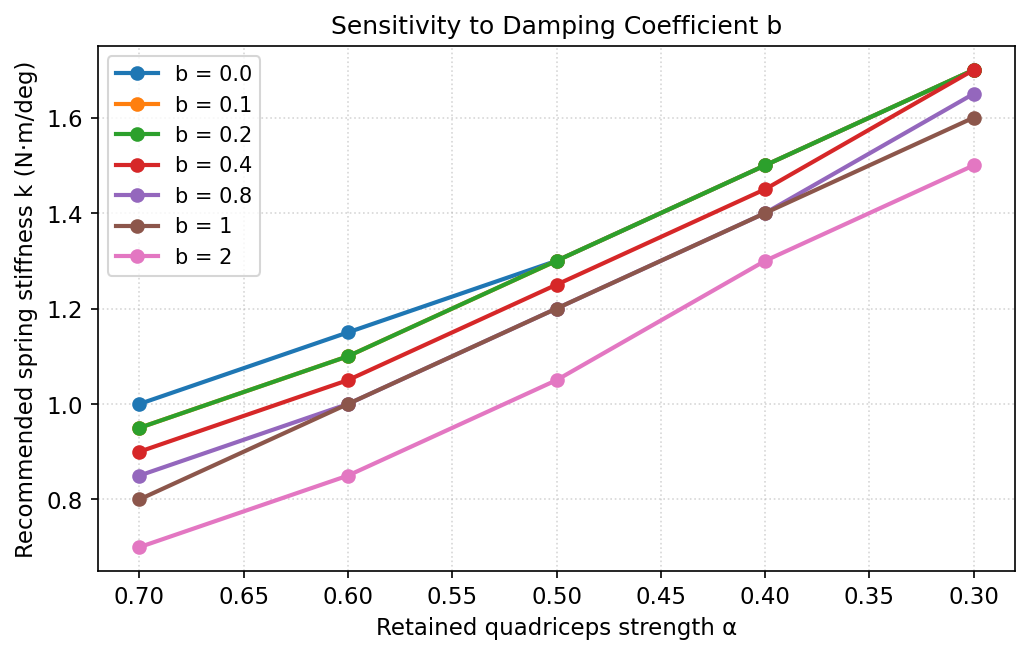

In [182]:
b_values = [0.0,0.1,0.2, 0.4, 0.8, 1, 2]
b_rows = []

for b_test in b_values:
    for alpha_s in alpha_levels:
        case = evaluate_case(alpha_s, 0.0, b_damp=b_test)
        # find k* for this b value
        k_grid_coarse = np.round(np.arange(0.0, 5.001, 0.25), 2)
        df_b, _, best_coarse = optimize_for_alpha(alpha_s, k_grid_coarse, b_damp=b_test)
        k_best = float(best_coarse['k_deg'])
        if str(best_coarse.get('selection_note', '')).startswith('feasible'):
            k_fine_min = max(0.0, k_best - 0.5)
            k_fine_max = min(5.0, k_best + 0.5)
            k_grid_fine = np.round(np.arange(k_fine_min, k_fine_max + 0.001, 0.05), 2)
            _, _, best = optimize_for_alpha(alpha_s, k_grid_fine, b_damp=b_test)
        else:
            best = best_coarse
        b_rows.append({'b': b_test, 'alpha': alpha_s, 'k_deg': float(best['k_deg'])})

b_df = pd.DataFrame(b_rows)

b_table = (b_df.pivot(index='alpha', columns='b', values='k_deg')
           .rename(columns={v: f'k (b={v})' for v in b_values})
           .reset_index())

print('Sensitivity to damping coefficient b')
print(b_table.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
for b_test in b_values:
    group = b_df[b_df['b'] == b_test]
    ax.plot(group['alpha'], group['k_deg'], marker='o', lw=2, label=f'b = {b_test}')
ax.set_xlabel('Retained quadriceps strength α')
ax.set_ylabel('Recommended spring stiffness k (N·m/deg)')
ax.set_title('Sensitivity to Damping Coefficient b')
ax.invert_xaxis()
ax.grid(True, ls=':', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('Figure11_SensitivityB.png', dpi=300, bbox_inches='tight')
plt.show()